In [1]:
!pip install tensorflow

In [3]:
import tensorflow
print(tensorflow.__version__)

2.21.0


C:\Users\hsiao\anaconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.1507 - loss: 2.2592 - val_accuracy: 0.1250 - val_loss: 2.0713 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.2991 - loss: 2.0374 - val_accuracy: 0.2917 - val_loss: 2.0078 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.3996 - loss: 1.8606 - val_accuracy: 0.3333 - val_loss: 1.7908 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.4386 - loss: 1.4435 - val_accuracy: 0.6667 - val_loss: 1.2855 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 339ms/step - accuracy: 0.5424 - loss: 0.9881 - val_accuracy: 0.7500 - val_loss: 0.9486 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.6741 - loss: 0.6129 - val_accuracy: 0.5417 - val_loss: 0.9697 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 262ms/step - accuracy: 0.7087 - loss: 0.5297 -

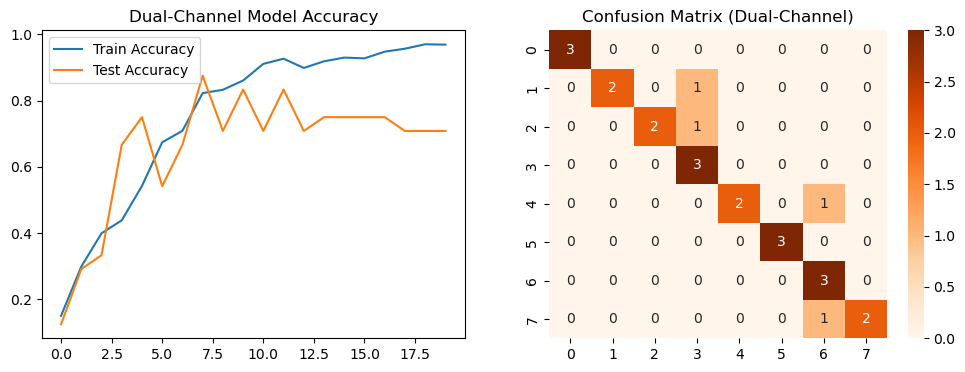

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.8333 - loss: 0.5433

最終測試資料正確率: 83.33%
模型自動最佳化的灰階影像權重 (Alpha): 0.4555
LBP 紋理影像權重 (1 - Alpha): 0.5445


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from skimage.feature import local_binary_pattern # 用於計算 LBP

# ==========================================
# 1. 資料讀取與雙通道預處理 (Grayscale + LBP)
# ==========================================
df = pd.read_csv(r"C:\cnn_project\CK+ Dataset.csv") 

def parse_and_extract_channels(pixel_str):
    # 1. 讀取並重塑為 48x48 灰階圖
    gray_img = np.array(pixel_str.split(), dtype='float32').reshape(48, 48)
    
    # 2. 計算 LBP 特徵 (採用經典的 8 鄰居, 半徑 1)
    # skimage 的 lbp 輸出依然是 48x48 的矩陣
    lbp_img = local_binary_pattern(gray_img, P=8, R=1, method='default').astype('float32')
    
    # 3. 回傳時增加通道維度 (48, 48, 1)
    return gray_img[:, :, np.newaxis], lbp_img[:, :, np.newaxis]

# 執行雙通道轉換
extracted = df['pixels'].apply(parse_and_extract_channels)
df['gray_matrix'] = [x[0] for x in extracted]
df['lbp_matrix'] = [x[1] for x in extracted]

# ==========================================
# 2. 嚴格遵守切割規則：每類最後 3 張為測試
# ==========================================
train_gray, test_gray = [], []
train_lbp, test_lbp = [], []
train_labels, test_labels = [], []

for emotion_id in range(8):
    emotion_df = df[df['emotion'] == emotion_id]
    test_subset = emotion_df.tail(3)
    train_subset = emotion_df.iloc[:-3]
    
    # 分配測試集
    test_gray.extend(test_subset['gray_matrix'].values)
    test_lbp.extend(test_subset['lbp_matrix'].values)
    test_labels.extend(test_subset['emotion'].values)
    
    # 分配訓練集
    train_gray.extend(train_subset['gray_matrix'].values)
    train_lbp.extend(train_subset['lbp_matrix'].values)
    train_labels.extend(train_subset['emotion'].values)

# 歸一化 (將灰階與 LBP 特徵皆限制在 0~1 之間)
X_train_gray = np.array(train_gray) / 255.0
X_test_gray = np.array(test_gray) / 255.0

# LBP 最大值為 255 (8位元)，同樣除以 255.0 歸一化
X_train_lbp = np.array(train_lbp) / 255.0
X_test_lbp = np.array(test_lbp) / 255.0

y_train = np.array(train_labels)
y_test = np.array(test_labels)

# 類別權重計算
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# ==========================================
# 3. 建立雙通道融合模型 (Functional API)
# ==========================================

# ----- 通道 A：灰階影像分支 (參考論文的 Partial VGG 概念) -----
input_gray = layers.Input(shape=(48, 48, 1), name='Gray_Input')
x1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_gray)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Flatten()(x1)
fv1 = layers.Dense(256, activation='relu', name='fv1_gray_features')(x1)
fv1 = layers.Dropout(0.5)(fv1)
fc1_2 = layers.Dense(8, name='fc1_2_gray_logits')(fv1) # 降維至類別數

# ----- 通道 B：LBP 紋理分支 (參考論文的 Shallow CNN 架構) -----
input_lbp = layers.Input(shape=(48, 48, 1), name='LBP_Input')
# C1: 大卷積核捕捉微觀細節
x2 = layers.Conv2D(64, (5, 5), padding='same', activation='relu')(input_lbp) 
s1 = layers.MaxPooling2D((2, 2))(x2)
# C2: 深層卷積
x2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(s1)
s2 = layers.MaxPooling2D((2, 2))(x2)
# 結合多尺度 (將 S1 降維後與 S2 拼接，模擬論文中的多尺度特徵連接)
s1_down = layers.MaxPooling2D((2, 2))(s1)
multi_scale = layers.concatenate([s2, s1_down])
x2_flat = layers.Flatten()(multi_scale)
fv2 = layers.Dense(256, activation='relu', name='fv2_lbp_features')(x2_flat)
fv2 = layers.Dropout(0.5)(fv2)
fc2_2 = layers.Dense(8, name='fc2_2_lbp_logits')(fv2) # 降維至類別數

# ----- 核心：加權融合層 (Weighted Fusion) -----
# 自定義一個簡單的加權融合層來實現：p = α * s + (1 - α) * l
class WeightedFusion(layers.Layer):
    def __init__(self, **kwargs):
        super(WeightedFusion, self).__init__(**kwargs)
        
    def build(self, input_shape):
        # 移除 constraint 參數，避免 Keras 版本相容性問題
        self.alpha = self.add_weight(name='alpha', 
                                     shape=(1,), 
                                     initializer=tf.keras.initializers.Constant(0.5), 
                                     trainable=True)
        super(WeightedFusion, self).build(input_shape)
        
    def call(self, inputs):
        fc1, fc2 = inputs
        
        # 直接在計算時使用 tf.clip_by_value，確保 alpha 在前向傳播時永遠鎖在 0.0 ~ 1.0 之間
        clipped_alpha = tf.clip_by_value(self.alpha, 0.0, 1.0)
        
        return clipped_alpha * fc1 + (1.0 - clipped_alpha) * fc2
fused_logits = WeightedFusion(name='Weighted_Fusion')([fc1_2, fc2_2])
output = layers.Activation('softmax', name='Softmax_Output')(fused_logits)

# 組裝雙輸入單輸出模型
model = models.Model(inputs=[input_gray, input_lbp], outputs=output)

# 設定損失函數：Cross Entropy
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. 訓練與優化策略 (配合雙輸入調整)
# ==========================================
# ==========================================
# 4. 訓練與優化策略 (改用新版 Keras 3 專用的 tf.data 封裝)
# ==========================================
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.2, patience=5)

# 依據輸入層的 name，用 dict 封裝訓練集與驗證集
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {"Gray_Input": X_train_gray, "LBP_Input": X_train_lbp}, 
        y_train
    )
).shuffle(buffer_size=len(X_train_gray)).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {"Gray_Input": X_test_gray, "LBP_Input": X_test_lbp}, 
        y_test
    )
).batch(32).prefetch(tf.data.AUTOTUNE)

# ==========================================
# 5. 開始訓練
# ==========================================
# 這裡不需要傳入 steps_per_epoch，tf.data 會自動計算
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)
# ==========================================
# 5. 產出報告所需的評估結果
# ==========================================
# 學習曲線
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Dual-Channel Model Accuracy')
plt.legend()

# 混淆矩陣
y_pred = model.predict([X_test_gray, X_test_lbp]).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix (Dual-Channel)')
plt.show()

# 顯示最終測試正確率與模型學到的 Alpha 值
test_loss, test_acc = model.evaluate([X_test_gray, X_test_lbp], y_test)
alpha_val = model.get_layer('Weighted_Fusion').get_weights()[0][0]
print(f"\n最終測試資料正確率: {test_acc*100:.2f}%")
print(f"模型自動最佳化的灰階影像權重 (Alpha): {alpha_val:.4f}")
print(f"LBP 紋理影像權重 (1 - Alpha): {1.0 - alpha_val:.4f}")

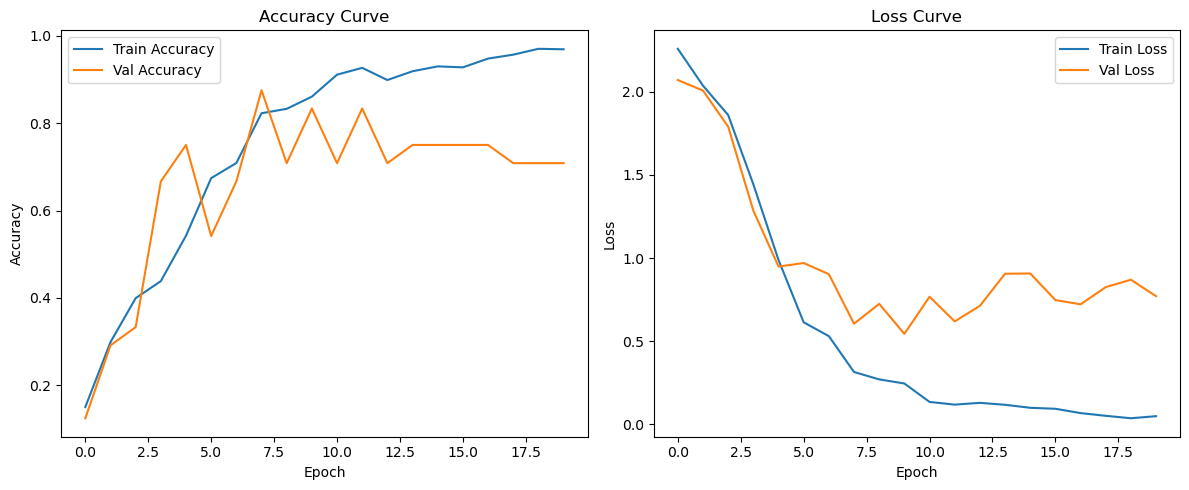

In [7]:
# ==========================
# Training Curves
# ==========================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()